# Dos pronúcleos compiten por el citoplasma en el zigoto

**54.7% vs 26.6%.** Dos zigotos arrancan la vida con la misma información genética. Uno llega a nacer la mitad de las veces que el otro. La diferencia está en algo que la clínica de fecundación in vitro a veces ignora: que el embrión tenía un solo núcleo en lugar de dos.

> **Paper:** [Cytoplasmic competition between separate parental pronuclei in zygotes](https://doi.org/10.1038/s41586-026-10417-7)
> *Nature, 2026 · Experimentos en zigotos de ratón con manipulación micromecánica + imaging cuantitativo*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-29-pronuclear-competition-zygotes/notebook.ipynb)

> **Video corto:** _Pendiente_

## El experimento

Cuando un óvulo y un espermatozoide se fusionan, los cromosomas maternos y paternos quedan **en dos compartimentos separados** dentro de la misma célula: dos pronúcleos (PN). Es la última vez que mamá y papá viven en burbujas distintas antes de mezclarse para siempre.

A veces — por error de fertilización, o por manipulación en una clínica de fecundación in vitro — todos los cromosomas terminan en **un solo pronúcleo** (1PN biparental). Genéticamente debería dar igual: la información está toda ahí. Y sin embargo, casi la mitad de estos embriones falla en llegar a término.

Un equipo japonés midió tres cosas en zigotos de ratón: cuánto crece cada pronúcleo, qué pasa con las marcas químicas que regulan los genes, y a cuántos embriones les fue bien. Aquí están sus datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_2PN = '#2563EB'         # Azul CaM — zigotos normales (2 pronúcleos)
COLOR_1PN = '#DC2626'         # Rojo — zigotos 1PN biparentales (problema)
COLOR_P1PN = '#D97706'        # Amber — P1PN, rescate experimental
COLOR_REF = '#BBBBBB'         # Gris — referencias
FUENTE = 'Fuente: Mihajlović et al. (2026), Nature | Datos: Source Data MOESM10 + MOESM14'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM — local si existe, fallback a raw GitHub
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga
df_vol = pd.read_csv('datos/fig1b_pronuclear_volumes.csv')
df_his = pd.read_csv('datos/fig1e_histone_marks.csv')
df_dev = pd.read_csv('datos/fig5b_development_rates.csv')

print(f'Volúmenes pronucleares: {len(df_vol)} mediciones')
print(f'Marcas de histonas:     {len(df_his)} mediciones')
print(f'Tasas de desarrollo:    {len(df_dev)} filas (lotes × etapa × tipo)')
print()
print('Tipos de zigoto:', df_vol['zygote_type'].unique().tolist())

Volúmenes pronucleares: 170 mediciones
Marcas de histonas:     190 mediciones
Tasas de desarrollo:    50 filas (lotes × etapa × tipo)

Tipos de zigoto: ['2PN', '1PN']


## Cuánto crece cada pronúcleo

Aquí está.

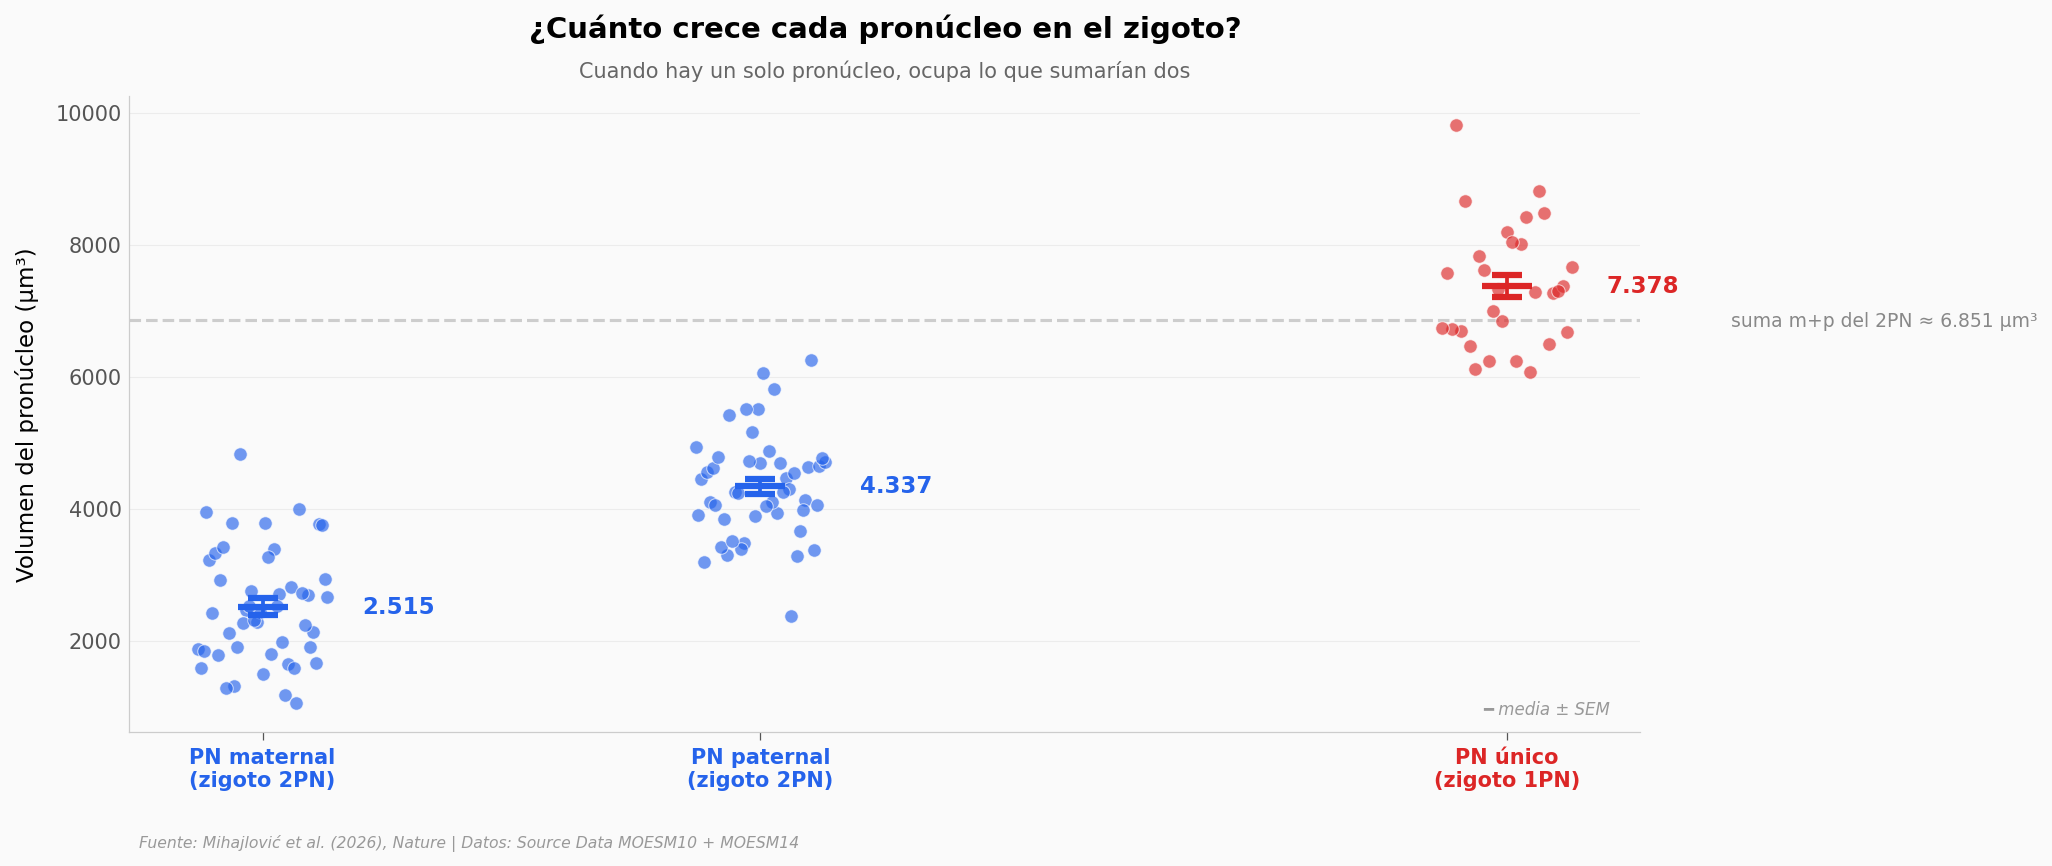

PN maternal: media = 2515 μm³ (n=47)
PN paternal: media = 4337 μm³ (n=47)
PN biparental 1PN: media = 7378 μm³ (n=29)
Razón biPN / (m+p) = 1.08x  → el PN único ocupa el 108% de lo que sumarían dos


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Tres grupos: maternal (2PN), paternal (2PN), biparental (1PN)
groups = [
    ('PN maternal\n(zigoto 2PN)',   df_vol[(df_vol.zygote_type=='2PN') & (df_vol.pronucleus=='maternal_PN')]['volume_um3'].values,  COLOR_2PN),
    ('PN paternal\n(zigoto 2PN)',   df_vol[(df_vol.zygote_type=='2PN') & (df_vol.pronucleus=='paternal_PN')]['volume_um3'].values,  COLOR_2PN),
    ('PN único\n(zigoto 1PN)',      df_vol[(df_vol.zygote_type=='1PN') & (df_vol.pronucleus=='biparental_PN')]['volume_um3'].values, COLOR_1PN),
]
positions = [0, 1, 2.5]
np.random.seed(42)
for i, (label, vals, color) in enumerate(groups):
    n = len(vals)
    x = np.linspace(positions[i] - 0.13, positions[i] + 0.13, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=color, s=42, alpha=0.65,
               edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                markersize=24, markeredgewidth=3,
                capsize=7, capthick=1.5, zorder=6)
    # Anotar la media en negrita
    ax.annotate(f'{mean:,.0f}'.replace(',', '.'), xy=(positions[i] + 0.20, mean),
                fontsize=11, fontweight='bold', color=color, va='center')

# Línea de referencia: suma maternal + paternal del 2PN
suma_2pn = groups[0][1].mean() + groups[1][1].mean()
ax.axhline(y=suma_2pn, color=COLOR_REF, linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
ax.text(2.95, suma_2pn, f'suma m+p del 2PN ≈ {suma_2pn:,.0f} μm³'.replace(',', '.'),
        fontsize=9, color='#888888', va='center')

ax.set_xticks(positions)
ax.set_xticklabels([g[0] for g in groups], fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_2PN, COLOR_2PN, COLOR_1PN]):
    tick.set_color(color)
ax.set_ylabel('Volumen del pronúcleo (μm³)', fontsize=11)
ax.set_title('¿Cuánto crece cada pronúcleo en el zigoto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuando hay un solo pronúcleo, ocupa lo que sumarían dos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/volumenes_pronucleares.png', dpi=200, bbox_inches='tight')
plt.show()

# Reportar números clave
mPN = groups[0][1]; pPN = groups[1][1]; biPN = groups[2][1]
ratio = biPN.mean() / (mPN.mean() + pPN.mean())
print(f'PN maternal: media = {mPN.mean():.0f} μm³ (n={len(mPN)})')
print(f'PN paternal: media = {pPN.mean():.0f} μm³ (n={len(pPN)})')
print(f'PN biparental 1PN: media = {biPN.mean():.0f} μm³ (n={len(biPN)})')
print(f'Razón biPN / (m+p) = {ratio:.2f}x  → el PN único ocupa el {100*ratio:.0f}% de lo que sumarían dos')

El pronúcleo paternal del zigoto normal es claramente más grande que el maternal — 4.337 frente a 2.515 μm³ en promedio (paternal 72% mayor, Cohen's *d* = 1.84, n = 47 zigotos con ambos pronúcleos medidos). Es una asimetría conocida: el ADN del padre llega más descondensado. Pero el dato que importa: el pronúcleo único del 1PN ocupa **el equivalente a sumar los dos del 2PN**.

Esto es exactamente lo que predice la idea de "recursos citoplasmáticos finitos". Hay una cantidad limitada de algo (proteínas de importación nuclear, lípidos de membrana, lo que sea) y los pronúcleos compiten por ello. Con dos compartimentos compitiendo, cada uno se queda con su parte. Con uno solo, se lleva todo el lote.

## ¿Qué pasa con las marcas químicas del ADN?

Que un pronúcleo crezca de más no es solo un problema de tamaño. Dentro del núcleo, las histonas — proteínas que empaquetan el ADN — llevan marcas químicas (metilaciones) que deciden qué genes se prenden y cuáles se apagan. Si el volumen cambia, las concentraciones de las enzimas que ponen y quitan esas marcas también cambian.

Veamos tres marcas distintas: H3K27me3, H3K4me3 y H3K9me3.

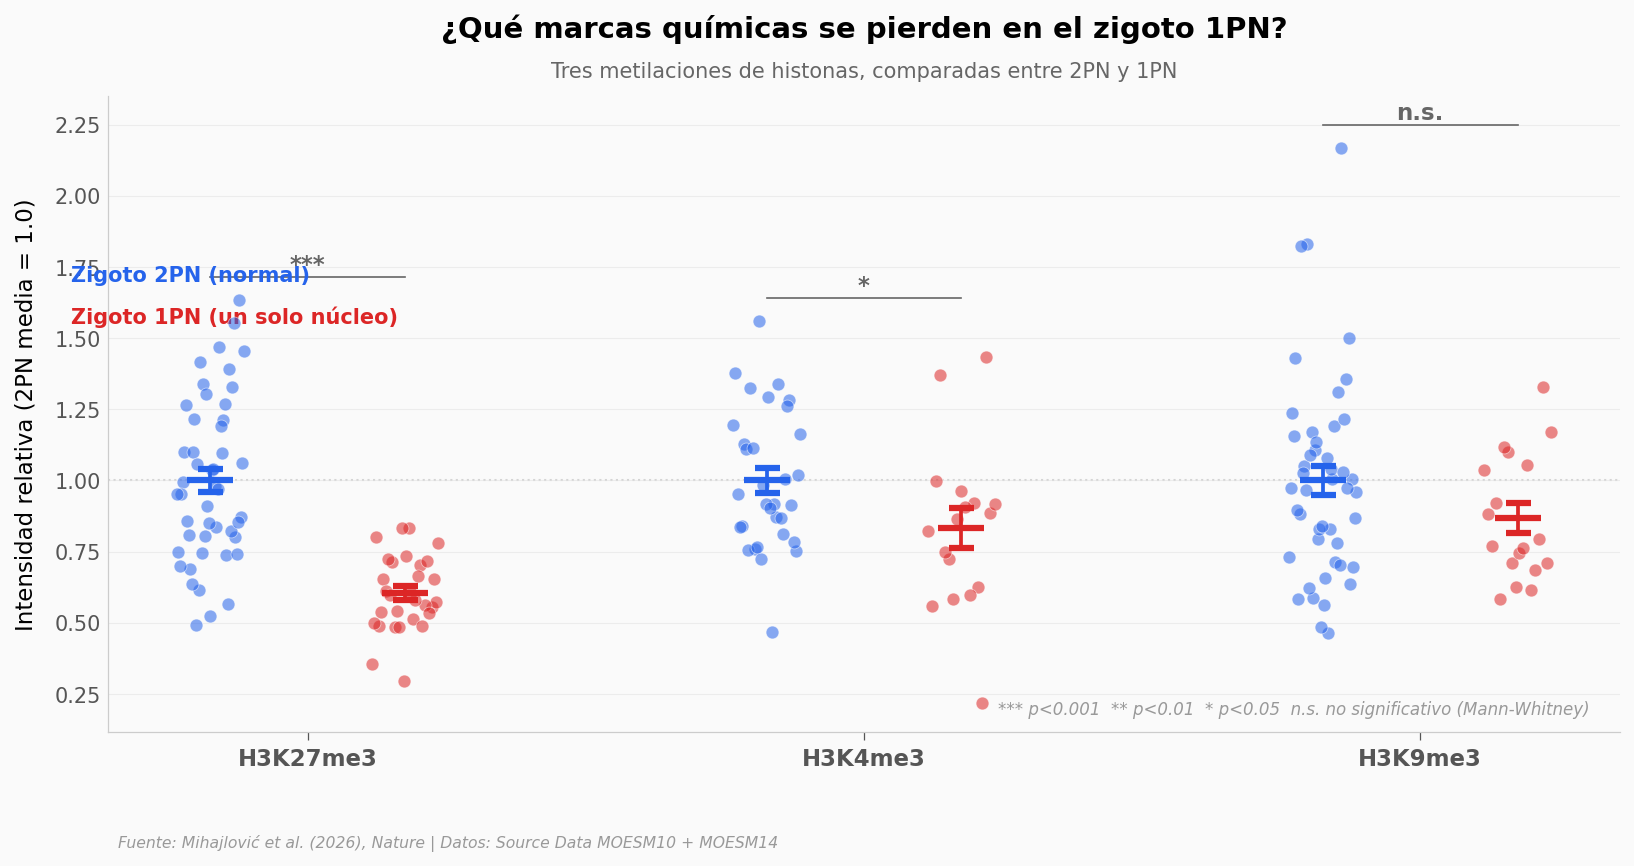

H3K27me3: 2PN=1.00  1PN=0.60  cambio=-39.6%  Cohen's d=1.66
H3K4me3: 2PN=1.00  1PN=0.83  cambio=-16.8%  Cohen's d=0.65
H3K9me3: 2PN=1.00  1PN=0.87  cambio=-13.2%  Cohen's d=0.41


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

marks_order = ['H3K27me3', 'H3K4me3', 'H3K9me3']
positions_2pn = [0, 2, 4]
positions_1pn = [0.7, 2.7, 4.7]

np.random.seed(42)
for i, mark in enumerate(marks_order):
    vals_2pn = df_his[(df_his['mark']==mark) & (df_his.zygote_type=='2PN')]['rel_intensity'].values
    vals_1pn = df_his[(df_his['mark']==mark) & (df_his.zygote_type=='1PN')]['rel_intensity'].values
    # 2PN scatter
    x2 = np.linspace(positions_2pn[i] - 0.12, positions_2pn[i] + 0.12, len(vals_2pn))
    np.random.shuffle(x2)
    ax.scatter(x2, vals_2pn, color=COLOR_2PN, s=38, alpha=0.55,
               edgecolors='white', linewidths=0.4, zorder=5)
    ax.errorbar(positions_2pn[i], vals_2pn.mean(),
                yerr=vals_2pn.std(ddof=1)/np.sqrt(len(vals_2pn)),
                fmt='_', color=COLOR_2PN, markersize=22, markeredgewidth=3,
                capsize=6, capthick=1.5, zorder=6)
    # 1PN scatter
    x1 = np.linspace(positions_1pn[i] - 0.12, positions_1pn[i] + 0.12, len(vals_1pn))
    np.random.shuffle(x1)
    ax.scatter(x1, vals_1pn, color=COLOR_1PN, s=38, alpha=0.55,
               edgecolors='white', linewidths=0.4, zorder=5)
    ax.errorbar(positions_1pn[i], vals_1pn.mean(),
                yerr=vals_1pn.std(ddof=1)/np.sqrt(len(vals_1pn)),
                fmt='_', color=COLOR_1PN, markersize=22, markeredgewidth=3,
                capsize=6, capthick=1.5, zorder=6)
    # Test Mann-Whitney
    u, p = stats.mannwhitneyu(vals_2pn, vals_1pn, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    y_top = max(vals_2pn.max(), vals_1pn.max()) + 0.08
    ax.plot([positions_2pn[i], positions_1pn[i]], [y_top, y_top], color='#666666', lw=0.8)
    ax.text((positions_2pn[i] + positions_1pn[i])/2, y_top + 0.02,
            sig, ha='center', fontsize=11, fontweight='bold', color='#666666')

ax.axhline(y=1.0, color=COLOR_REF, linestyle=':', linewidth=1, alpha=0.6, zorder=1)

# Inline labels
ax.text(-0.5, 1.7, 'Zigoto 2PN (normal)', fontsize=10, color=COLOR_2PN, fontweight='bold')
ax.text(-0.5, 1.55, 'Zigoto 1PN (un solo núcleo)', fontsize=10, color=COLOR_1PN, fontweight='bold')

ax.set_xticks([(p2+p1)/2 for p2, p1 in zip(positions_2pn, positions_1pn)])
ax.set_xticklabels(marks_order, fontsize=11, fontweight='bold')
ax.set_ylabel('Intensidad relativa (2PN media = 1.0)', fontsize=11)
ax.set_title('¿Qué marcas químicas se pierden en el zigoto 1PN?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tres metilaciones de histonas, comparadas entre 2PN y 1PN',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '*** p<0.001  ** p<0.01  * p<0.05  n.s. no significativo (Mann-Whitney)',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/marcas_histonas.png', dpi=200, bbox_inches='tight')
plt.show()

# Cohen's d
for mark in marks_order:
    v2 = df_his[(df_his['mark']==mark) & (df_his.zygote_type=='2PN')]['rel_intensity'].values
    v1 = df_his[(df_his['mark']==mark) & (df_his.zygote_type=='1PN')]['rel_intensity'].values
    pooled = np.sqrt(((len(v2)-1)*v2.var(ddof=1) + (len(v1)-1)*v1.var(ddof=1)) / (len(v2)+len(v1)-2))
    d = (v2.mean() - v1.mean()) / pooled
    diff = (v1.mean() - v2.mean()) / v2.mean() * 100
    print(f'{mark}: 2PN={v2.mean():.2f}  1PN={v1.mean():.2f}  cambio={diff:+.1f}%  Cohen\'s d={d:.2f}')

La marca que se cae a pedazos es **H3K27me3** — el efecto es enorme (Cohen's *d* = 1.66, prácticamente sin solapamiento entre grupos). Las otras dos se mueven menos: H3K4me3 baja un poco, H3K9me3 no se distingue del ruido.

H3K27me3 no es cualquier marca: es la responsable de mantener silenciados los genes que el embrión no debe encender todavía. Si se pierde, esos genes podrían activarse antes de tiempo. La pregunta entonces es directa: **¿cuántos de estos embriones sobreviven?**

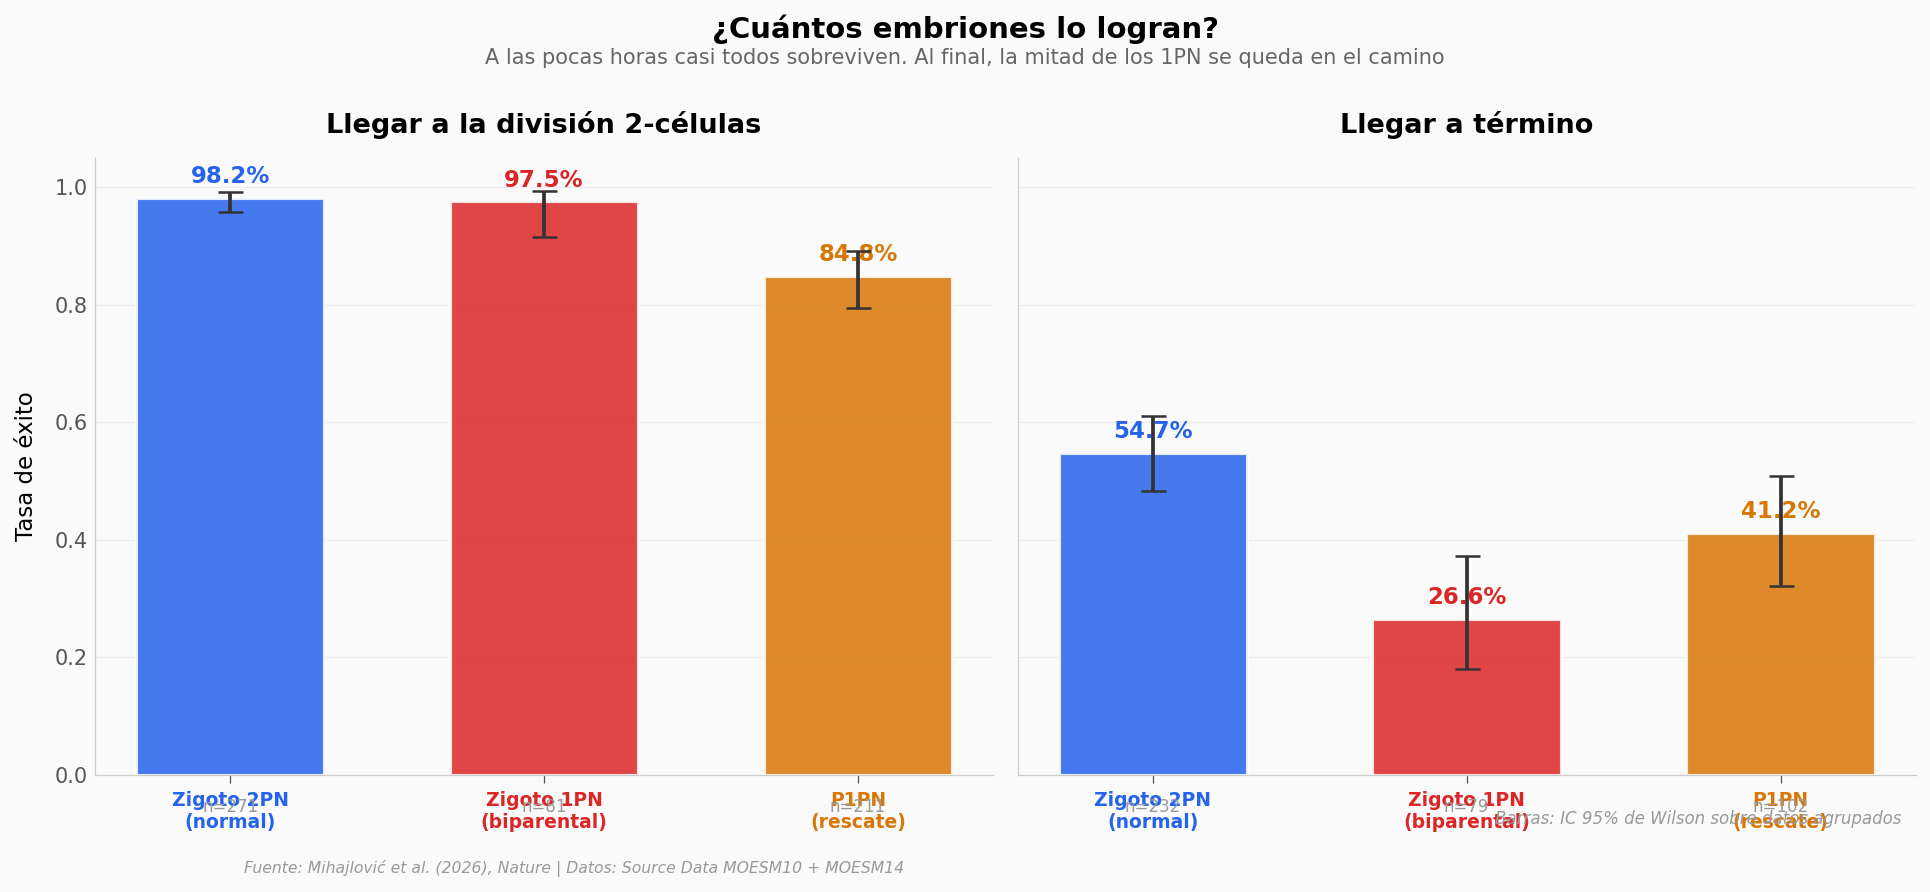

2PN full-term: 127/232 = 54.7%
1PN full-term: 21/79 = 26.6%
χ² = 17.62, p = 2.69e-05


In [4]:
# Agregar lotes — usar promedio ponderado por n (regla 34)
def pooled_rate(df, stage, ztype):
    sub = df[(df.developmental_stage==stage) & (df.zygote_type==ztype)]
    return sub['successful'].sum() / sub['total'].sum(), sub['successful'].sum(), sub['total'].sum()

stages = ['2cell', 'full_term']
ztypes = [('2PN', COLOR_2PN, 'Zigoto 2PN\n(normal)'),
          ('1PN', COLOR_1PN, 'Zigoto 1PN\n(biparental)'),
          ('P1PN', COLOR_P1PN, 'P1PN\n(rescate)')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

for ax_idx, stage in enumerate(stages):
    ax = axes[ax_idx]
    for i, (zt, color, label) in enumerate(ztypes):
        rate, k, n = pooled_rate(df_dev, stage, zt)
        # Wilson CI 95%
        from math import sqrt
        z = 1.96
        denom = 1 + z**2/n
        center = (rate + z**2/(2*n)) / denom
        margin = z * sqrt(rate*(1-rate)/n + z**2/(4*n**2)) / denom
        ci_low = max(0, center - margin)
        ci_high = min(1, center + margin)
        ax.bar(i, rate, color=color, alpha=0.85, width=0.6,
               edgecolor='white', linewidth=1.5, zorder=3)
        ax.errorbar(i, rate, yerr=[[rate-ci_low], [ci_high-rate]],
                    fmt='none', color='#333333', capsize=6, capthick=1.2, zorder=4)
        ax.text(i, rate + 0.025, f'{100*rate:.1f}%', ha='center',
                fontsize=11, fontweight='bold', color=color)
        ax.text(i, -0.06, f'n={n}', ha='center', fontsize=8, color='#999999',
                transform=ax.get_xaxis_transform())
    ax.set_xticks(range(len(ztypes)))
    ax.set_xticklabels([z[2] for z in ztypes], fontsize=9, fontweight='bold')
    for tick, color in zip(ax.get_xticklabels(), [z[1] for z in ztypes]):
        tick.set_color(color)
    ax.set_ylim(0, 1.05)
    if ax_idx == 0:
        ax.set_ylabel('Tasa de éxito', fontsize=11)
    title_es = 'Llegar a la división 2-células' if stage == '2cell' else 'Llegar a término'
    ax.set_title(title_es, fontsize=13, fontweight='bold', pad=12)

fig.suptitle('¿Cuántos embriones lo logran?',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.96, 'A las pocas horas casi todos sobreviven. Al final, la mitad de los 1PN se queda en el camino',
         ha='center', fontsize=10, color='#666666')
fig.text(0.98, 0.04, 'Barras: IC 95% de Wilson sobre datos agrupados',
         transform=fig.transFigure, fontsize=8, color='#999999', ha='right', style='italic')
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/tasas_desarrollo.png', dpi=200, bbox_inches='tight')
plt.show()

# Test χ² 2PN vs 1PN para full-term
ft_2pn = df_dev[(df_dev.developmental_stage=='full_term') & (df_dev.zygote_type=='2PN')]
ft_1pn = df_dev[(df_dev.developmental_stage=='full_term') & (df_dev.zygote_type=='1PN')]
table = np.array([[ft_2pn.successful.sum(), ft_2pn.total.sum() - ft_2pn.successful.sum()],
                  [ft_1pn.successful.sum(), ft_1pn.total.sum() - ft_1pn.successful.sum()]])
chi2, p, _, _ = stats.chi2_contingency(table)
print(f'2PN full-term: {ft_2pn.successful.sum()}/{ft_2pn.total.sum()} = {100*ft_2pn.successful.sum()/ft_2pn.total.sum():.1f}%')
print(f'1PN full-term: {ft_1pn.successful.sum()}/{ft_1pn.total.sum()} = {100*ft_1pn.successful.sum()/ft_1pn.total.sum():.1f}%')
print(f'χ² = {chi2:.2f}, p = {p:.2e}')

## ¿Cuán raro es el pronúcleo 1PN comparado con los 2PN?

A las pocas horas (etapa 2-células) ambos grupos van casi igual: 98% lo logra. Es al final del embarazo cuando se abre la brecha: **27% vs 55%**, prácticamente la mitad. El rescate experimental P1PN — donde inyectan otro pronúcleo de un huevo no fecundado para forzar la competencia — recupera al 41%, partiendo la diferencia.

Veamos esa anomalía del volumen pronuclear de otra forma: ¿dónde cae el zigoto 1PN dentro de la distribución de zigotos 2PN normales?

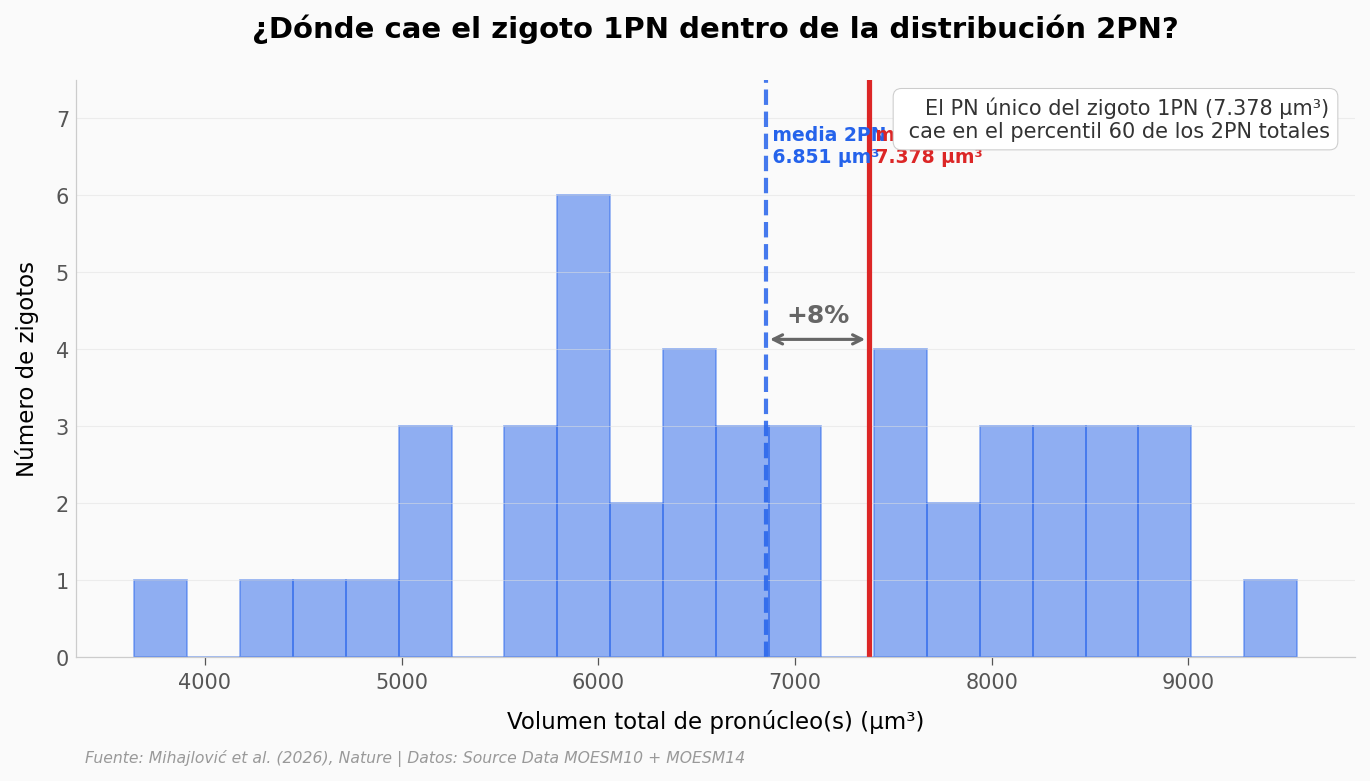

Volumen total 2PN: media = 6851, mediana = 6672 μm³ (n=47)
Volumen único 1PN: media = 7378, mediana = 7292 μm³ (n=29)
El 1PN cae en el percentil 60 de la distribución 2PN total


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

vol_2pn_total = df_vol[(df_vol.zygote_type=='2PN') & (df_vol.pronucleus=='total_combined')]['volume_um3'].values
vol_1pn_biPN  = df_vol[(df_vol.zygote_type=='1PN') & (df_vol.pronucleus=='biparental_PN')]['volume_um3'].values

n, bins, patches = ax.hist(vol_2pn_total, bins=22, color=COLOR_2PN, alpha=0.5,
                            edgecolor=COLOR_2PN, linewidth=0.8, label='Zigotos 2PN (suma m+p)')
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Media 2PN total
media_2pn = vol_2pn_total.mean()
ax.axvline(x=media_2pn, color=COLOR_2PN, linewidth=2, linestyle='--', alpha=0.85)
ax.text(media_2pn, y_max*0.92, f' media 2PN\n {media_2pn:,.0f} μm³'.replace(',', '.'),
        fontsize=9, color=COLOR_2PN, fontweight='bold', va='top')

# Media 1PN biparental
media_1pn = vol_1pn_biPN.mean()
ax.axvline(x=media_1pn, color=COLOR_1PN, linewidth=2.5)
ax.text(media_1pn, y_max*0.92, f' media 1PN\n {media_1pn:,.0f} μm³'.replace(',', '.'),
        fontsize=9, color=COLOR_1PN, fontweight='bold', va='top')

# Flecha
y_arrow = y_max * 0.55
ax.annotate('', xy=(media_1pn, y_arrow), xytext=(media_2pn, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media_2pn + media_1pn) / 2, y_arrow + y_max*0.03,
        f'+{100*(media_1pn-media_2pn)/media_2pn:.0f}%',
        ha='center', fontsize=12, fontweight='bold', color='#666666')

# Percentil del media-1PN dentro de la distribución 2PN
percentil = stats.percentileofscore(vol_2pn_total, media_1pn)
ax.text(0.98, 0.97,
        f'El PN único del zigoto 1PN ({media_1pn:,.0f} μm³)\n cae en el percentil {percentil:.0f} de los 2PN totales'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color='#333333', ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC'))

ax.set_xlabel('Volumen total de pronúcleo(s) (μm³)', fontsize=11)
ax.set_ylabel('Número de zigotos', fontsize=11)
ax.set_title('¿Dónde cae el zigoto 1PN dentro de la distribución 2PN?',
             fontsize=14, fontweight='bold', pad=20)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_volumen.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Volumen total 2PN: media = {media_2pn:.0f}, mediana = {np.median(vol_2pn_total):.0f} μm³ (n={len(vol_2pn_total)})')
print(f'Volumen único 1PN: media = {media_1pn:.0f}, mediana = {np.median(vol_1pn_biPN):.0f} μm³ (n={len(vol_1pn_biPN)})')
print(f'El 1PN cae en el percentil {percentil:.0f} de la distribución 2PN total')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El PN paternal del 2PN es más grande que el maternal | ✅ | 4.337 vs 2.515 μm³ (paternal 72% mayor). Es asimetría conocida — el ADN paterno llega más descondensado. |
| El PN único del 1PN ocupa lo que sumarían los dos del 2PN | ✅ | 7.378 vs 6.851 μm³ (razón 1.08x). Consistente con la hipótesis de recursos citoplasmáticos finitos. |
| El zigoto 1PN pierde H3K27me3 | ✅ | Cae ~40% (Cohen's *d* = 1.66, p = 2×10⁻⁹, Mann-Whitney). Efecto muy grande. |
| Las otras dos marcas también se pierden | ⚠️ | H3K4me3 cae 17% (*d* = 0.65, p = 0.047) — efecto moderado, justo en el límite. H3K9me3 no se distingue del ruido (*d* = 0.41, p = 0.21). El paper agrupa como "marcas trimetiladas" pero el peso narrativo es H3K27me3. |
| 1PN tiene tasa de desarrollo a término reducida | ✅ | 27% vs 55% (χ² = 17.6, p = 3×10⁻⁵). Casi la mitad. |
| El rescate P1PN recupera parcialmente | ✅ | 41% — intermedio entre 27% y 55%. Sugiere que la pérdida es reversible si se restaura la competencia. |
| Hay un mecanismo de "competencia por citoplasma" entre pronúcleos | ⚠️ | Los datos son consistentes con esa idea, pero el abstract usa *suggesting* y *provides evidence of*. Estos son experimentos en ratón con manipulación micromecánica: el siguiente paso sería identificar la molécula limitante concreta. |

> **Limitaciones:**
> - Todos los experimentos son en zigotos de **ratón** — la traducción cuantitativa a humano requiere validación.
> - El rescate P1PN inyecta un pronúcleo de un huevo no fecundado: no es lo que ocurriría espontáneamente en una clínica.
> - El paper no identifica la molécula citoplasmática limitante — propone que existe, pero no la nombra.
> - El IC 95% de las tasas full-term es ancho para los grupos pequeños (1PN: n=79; P1PN: n=102 acumulado sobre 5 lotes); los lotes individuales son aún más ruidosos.

## Ahora tú

1. **¿Y si miramos paternal vs maternal del 2PN como histogramas separados?** ¿La asimetría se ve también en la dispersión, no solo en la media? *Pista: filtra por `pronucleus == 'maternal_PN'` y `paternal_PN`, y usa `ax.hist()` con `alpha=0.5` para superponer.*

2. **¿Cómo varían las tasas full-term entre lotes experimentales del 1PN?** *Pista: agrupa `df_dev` por `experiment_batch` para `developmental_stage == 'full_term'` y revisa cuánto se mueve la tasa lote a lote.*

3. **¿La pérdida de H3K27me3 correlaciona con el tamaño del pronúcleo único?** Los datos del paper no permiten emparejar volúmenes con intensidades a nivel de embrión individual (vienen agregados), pero puedes comparar los promedios entre subgrupos para hacerte una idea.

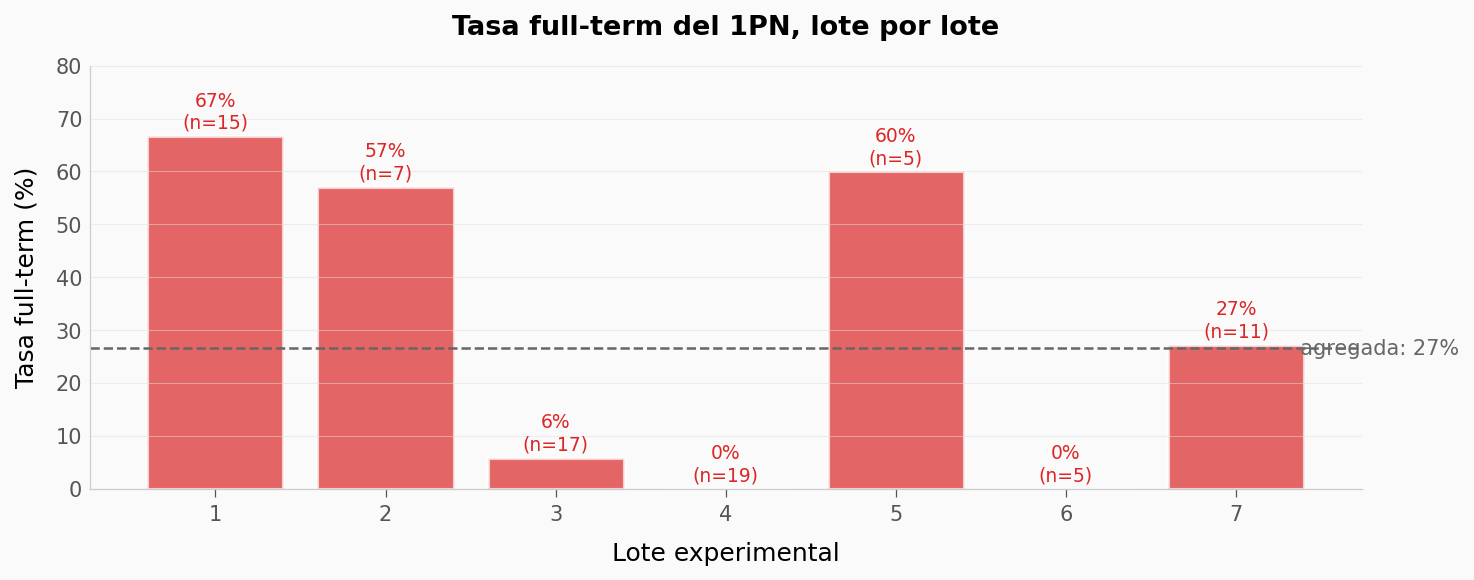


Dispersión entre lotes:
  rango: 0.0% a 66.7%
  media simple: 31.0%
  media ponderada (correcta): 26.6%


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿Cuánto varía la tasa full-term del 1PN entre los 5 lotes?

ft_1pn_lotes = df_dev[(df_dev.developmental_stage == 'full_term') & (df_dev.zygote_type == '1PN')].copy()
ft_1pn_lotes['rate_pct'] = 100 * ft_1pn_lotes['rate']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ft_1pn_lotes['experiment_batch'], ft_1pn_lotes['rate_pct'],
       color=COLOR_1PN, alpha=0.7, edgecolor='white', linewidth=1.5)
for _, row in ft_1pn_lotes.iterrows():
    ax.text(row['experiment_batch'], row['rate_pct'] + 1.5,
            f"{row['rate_pct']:.0f}%\n(n={row['total']})",
            ha='center', fontsize=9, color=COLOR_1PN)
# Línea de la tasa agregada
rate_agregada, k, n = pooled_rate(df_dev, 'full_term', '1PN')
ax.axhline(y=100*rate_agregada, color='#666666', linestyle='--', linewidth=1.2)
ax.text(ft_1pn_lotes['experiment_batch'].max() + 0.3, 100*rate_agregada,
        f'  agregada: {100*rate_agregada:.0f}%', fontsize=10, color='#666666', va='center')
ax.set_xlabel('Lote experimental')
ax.set_ylabel('Tasa full-term (%)')
ax.set_title('Tasa full-term del 1PN, lote por lote',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(ft_1pn_lotes['experiment_batch'])
ax.set_ylim(0, max(ft_1pn_lotes['rate_pct'].max() * 1.2, 50))
plt.tight_layout()
plt.show()

print(f'\nDispersión entre lotes:')
print(f'  rango: {ft_1pn_lotes.rate_pct.min():.1f}% a {ft_1pn_lotes.rate_pct.max():.1f}%')
print(f'  media simple: {ft_1pn_lotes.rate_pct.mean():.1f}%')
print(f'  media ponderada (correcta): {100*rate_agregada:.1f}%')

---

## Fuentes

**Paper**: [Cytoplasmic competition between separate parental pronuclei in zygotes](https://doi.org/10.1038/s41586-026-10417-7)  
*Nature, 2026-04-29*

**Source Data**: [Source Data Fig. 1 (volúmenes pronucleares + intensidades de histonas)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10417-7/MediaObjects/41586_2026_10417_MOESM10_ESM.xlsx)

**Source Data**: [Source Data Fig. 5 (tasas de desarrollo 2-cell y full-term)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10417-7/MediaObjects/41586_2026_10417_MOESM14_ESM.xlsx)

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

*Generado por [Ciencia a Mordiscos](https://cienciaamordiscos.com) — Lab. Notebook reproducible: clona el repo, abre en Jupyter, ejecuta.*

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)